# Level 2 Destination-Charging Suitability

## Goal

Identify block groups where public Level 2 charging could serve residents and visitors during longer dwell times. The model combines community-access need, market demand, destination opportunity, and distance from existing Level 2 charging.

Destination source: OpenStreetMap contributors via the daily Geofabrik Georgia extract.

## Context & Methods

### Key assumptions

- OpenStreetMap completeness varies by location and feature type.
- Destination points indicate opportunity, not confirmed parking ownership, electrical service, or permission to install chargers.
- Parking receives the highest opportunity weight because it is directly relevant to vehicle dwell time.
- The model ranks block groups for candidate-site investigation; it does not recommend individual parcels.
- The reproducible local workflow uses mapped destination nodes. Polygon-only destinations are excluded because statewide polygon extraction was not performant in the local Windows environment.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
CANDIDATE_DIR = PROJECT_ROOT / "data" / "raw" / "candidate_sites"
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"
for folder in [CANDIDATE_DIR, SPATIAL_DIR, TABLE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

gap_path = SPATIAL_DIR / "charging_gap_block_groups.gpkg"
station_path = SPATIAL_DIR / "existing_ev_charging_units.gpkg"
if not gap_path.exists() or not station_path.exists():
    raise FileNotFoundError("Run notebooks 03–05 before the Level 2 destination model.")

gap = gpd.read_file(gap_path, layer="charging_gaps").to_crs("EPSG:4326")
charging_units = gpd.read_file(station_path, layer="charging_units").to_crs("EPSG:4326")
study_boundary = gap.geometry.union_all() if hasattr(gap.geometry, "union_all") else gap.geometry.unary_union
west, south, east, north = gap.total_bounds
bbox = f"{south},{west},{north},{east}"

print("Study-area bounding box:", bbox)
print("Block groups:", len(gap))

Study-area bounding box: 33.596919,-84.277093,34.514096,-83.24086
Block groups: 926


## Data

### 1. Load destination points from a local Georgia OpenStreetMap extract

The daily Georgia `.osm.pbf` extract is downloaded once and cached locally. Reading the point layer avoids dependence on live Overpass servers. The query is bounded to the study-area extent and retains only the destination categories used by the Level 2 model.

In [2]:
import re
import pyogrio

OSM_PBF_URL = "https://download.geofabrik.de/north-america/us/georgia-latest.osm.pbf"
osm_pbf_path = CANDIDATE_DIR / "georgia-latest.osm.pbf"
if not osm_pbf_path.exists():
    request = Request(OSM_PBF_URL, headers={"User-Agent": "GIS-Portfolio-EV-Suitability/1.0"})
    with urlopen(request, timeout=900) as response, osm_pbf_path.open("wb") as output:
        while chunk := response.read(1024 * 1024):
            output.write(chunk)

tag_filters = {
    "amenity": ["parking", "library", "hospital", "clinic", "university", "college", "townhall", "community_centre"],
    "shop": ["mall", "supermarket", "department_store"],
    "tourism": ["hotel"],
    "leisure": ["park", "sports_centre", "fitness_centre"],
}
conditions = [
    f'''other_tags LIKE '%"{key}"=>"{value}"%' '''
    for key, values in tag_filters.items()
    for value in values
]
point_sql = "SELECT * FROM points WHERE " + " OR ".join(conditions)
osm_points = pyogrio.read_dataframe(
    osm_pbf_path,
    sql=point_sql,
    sql_dialect="SQLITE",
    bbox=(west, south, east, north),
)


def parse_other_tags(value):
    if not isinstance(value, str):
        return {}
    return dict(re.findall(r'"([^"]+)"=>"([^"]*)"', value))


records = []
for row in osm_points.itertuples(index=False):
    tags = parse_other_tags(row.other_tags)
    records.append({
        "osm_type": "node",
        "osm_id": row.osm_id,
        "name": row.name,
        "amenity": tags.get("amenity"),
        "shop": tags.get("shop"),
        "tourism": tags.get("tourism"),
        "leisure": tags.get("leisure"),
        "access": tags.get("access"),
        "capacity": tags.get("capacity"),
        "geometry": row.geometry,
    })

destinations = gpd.GeoDataFrame(records, crs="EPSG:4326")
destinations = destinations.loc[destinations.within(study_boundary)].copy()
destinations = destinations.drop_duplicates(subset=["osm_type", "osm_id"])
assert len(destinations) >= 300, "Destination count is unexpectedly low; check the local OSM extract."

snapshot_date = datetime.fromtimestamp(osm_pbf_path.stat().st_mtime, timezone.utc).date().isoformat()
metadata_path = CANDIDATE_DIR / "osm_level2_destination_extract_metadata.json"
metadata_path.write_text(
    json.dumps({
        "source": OSM_PBF_URL,
        "local_file": str(osm_pbf_path),
        "local_modified_date": snapshot_date,
        "feature_scope": "OSM point features only",
        "study_bbox": [west, south, east, north],
        "retained_features": len(destinations),
    }, indent=2),
    encoding="utf-8",
)
print(f"Destination point features inside study area: {len(destinations):,}")
print("Local extract:", osm_pbf_path)
print("Metadata:", metadata_path)

Destination point features inside study area: 489
Local extract: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\data\raw\candidate_sites\georgia-latest.osm.pbf
Metadata: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\data\raw\candidate_sites\osm_level2_destination_extract_metadata.json


### 2. Classify and weight destination opportunities

In [3]:
def classify_destination(row):
    if row["amenity"] == "parking":
        return "Parking"
    if pd.notna(row["shop"]):
        return "Retail"
    if row["amenity"] in {"hospital", "clinic"}:
        return "Health care"
    if row["amenity"] in {"university", "college"}:
        return "Education"
    if row["amenity"] in {"library", "townhall", "community_centre"}:
        return "Civic"
    if row["tourism"] == "hotel":
        return "Lodging"
    return "Recreation"

weights = {
    "Parking": 3.0, "Retail": 2.0, "Health care": 2.0,
    "Education": 2.0, "Civic": 2.0, "Lodging": 2.0, "Recreation": 1.0,
}
destinations["destination_type"] = destinations.apply(classify_destination, axis=1)
destinations["opportunity_weight"] = destinations["destination_type"].map(weights)
destinations.to_file(SPATIAL_DIR / "level2_destination_opportunities.gpkg", layer="destinations", driver="GPKG")

destination_summary = (
    destinations.groupby("destination_type", as_index=False)
    .agg(features=("osm_id", "count"), weighted_opportunity=("opportunity_weight", "sum"))
    .sort_values("weighted_opportunity", ascending=False)
)
display(destination_summary)

,destination_type,features,weighted_opportunity
6,Retail,172,344.0
5,Recreation,187,187.0
4,Parking,41,123.0
2,Health care,39,78.0
3,Lodging,26,52.0
0,Civic,19,38.0
1,Education,5,10.0


## Results

### 3. Aggregate destinations and calculate the existing Level 2 gap

In [4]:
destination_join = gpd.sjoin(
    destinations[["osm_id", "destination_type", "opportunity_weight", "geometry"]],
    gap[["GEOID", "geometry"]], how="inner", predicate="within",
)
destination_totals = (
    destination_join.groupby("GEOID", as_index=False)
    .agg(destination_features=("osm_id", "count"), destination_opportunity=("opportunity_weight", "sum"))
)

model = gap.merge(destination_totals, on="GEOID", how="left", validate="one_to_one")
model[["destination_features", "destination_opportunity"]] = model[
    ["destination_features", "destination_opportunity"]
].fillna(0)

charging_units["EV Level2 EVSE Num"] = pd.to_numeric(
    charging_units.get("EV Level2 EVSE Num", 0), errors="coerce"
).fillna(0)
level2_stations = charging_units.loc[charging_units["EV Level2 EVSE Num"] > 0].drop_duplicates("ID").copy()
assert not level2_stations.empty, "No existing Level 2 stations were found."

DISTANCE_CRS = "EPSG:5070"
METERS_PER_MILE = 1609.344
model_projected = model.to_crs(DISTANCE_CRS)
centers = model_projected[["GEOID", "geometry"]].copy()
centers["geometry"] = model_projected.geometry.representative_point()
nearest_level2 = gpd.sjoin_nearest(
    centers, level2_stations.to_crs(DISTANCE_CRS)[["ID", "geometry"]],
    how="left", distance_col="nearest_level2_meters",
).sort_values("nearest_level2_meters").drop_duplicates("GEOID")
distance_table = nearest_level2[["GEOID", "nearest_level2_meters"]]
model = model.merge(distance_table, on="GEOID", validate="one_to_one")
model["nearest_level2_miles"] = model["nearest_level2_meters"] / METERS_PER_MILE

### 4. Calculate Level 2 destination suitability

In [5]:
def percentile(series):
    return series.rank(pct=True, method="average")

model["destination_opportunity_score"] = 100 * percentile(model["destination_opportunity"])
model["level2_distance_gap_score"] = 100 * percentile(model["nearest_level2_miles"])
model["level2_suitability_score"] = (
    0.30 * model["public_access_need_index"] +
    0.25 * model["market_demand_index"] +
    0.25 * model["destination_opportunity_score"] +
    0.20 * model["level2_distance_gap_score"]
)
threshold = model["level2_suitability_score"].quantile(0.75)
model["level2_priority"] = np.where(
    model["level2_suitability_score"] >= threshold, "High relative priority", "Other"
)

model.to_file(SPATIAL_DIR / "level2_destination_suitability.gpkg", layer="level2_suitability", driver="GPKG")
ranking_fields = [
    "GEOID", "county_name", "population", "destination_features", "destination_opportunity",
    "nearest_level2_miles", "public_access_need_index", "market_demand_index",
    "destination_opportunity_score", "level2_distance_gap_score",
    "level2_suitability_score", "level2_priority",
]
ranking = model[ranking_fields].sort_values("level2_suitability_score", ascending=False)
ranking.to_csv(TABLE_DIR / "level2_destination_suitability_ranking.csv", index=False)
display(ranking.head(20).round(2))

,GEOID,county_name,population,destination_features,destination_opportunity,nearest_level2_miles,public_access_need_index,market_demand_index,destination_opportunity_score,level2_distance_gap_score,level2_suitability_score,level2_priority
514,131350505393,Gwinnett,2165,1.0,2.0,2.21,90.44,74.80,83.86,64.90,79.78,High relative priority
837,131350502232,Gwinnett,2309,2.0,3.0,1.27,95.92,82.85,90.55,38.01,79.73,High relative priority
886,132971107022,Walton,1727,3.0,3.0,9.48,79.54,50.63,90.55,97.84,78.72,High relative priority
775,131350504492,Gwinnett,1383,1.0,2.0,2.35,84.76,74.04,83.86,67.82,78.47,High relative priority
492,131350504382,Gwinnett,931,1.0,2.0,2.41,87.81,59.18,83.86,69.76,76.05,High relative priority
923,130590012003,Clarke,1399,8.0,10.0,1.02,91.41,70.15,98.87,28.51,75.38,High relative priority
297,130590022002,Clarke,1292,5.0,12.0,1.22,87.10,65.88,99.46,35.85,74.64,High relative priority
621,131350505542,Gwinnett,1267,1.0,2.0,2.96,62.98,75.17,83.86,78.29,74.31,High relative priority
58,131390010083,Hall,1738,2.0,4.0,0.83,95.23,72.02,93.63,20.09,74.00,High relative priority
71,131390007031,Hall,1702,1.0,1.0,2.00,86.23,67.49,75.27,60.26,73.61,High relative priority


### 5. Map Level 2 destination suitability

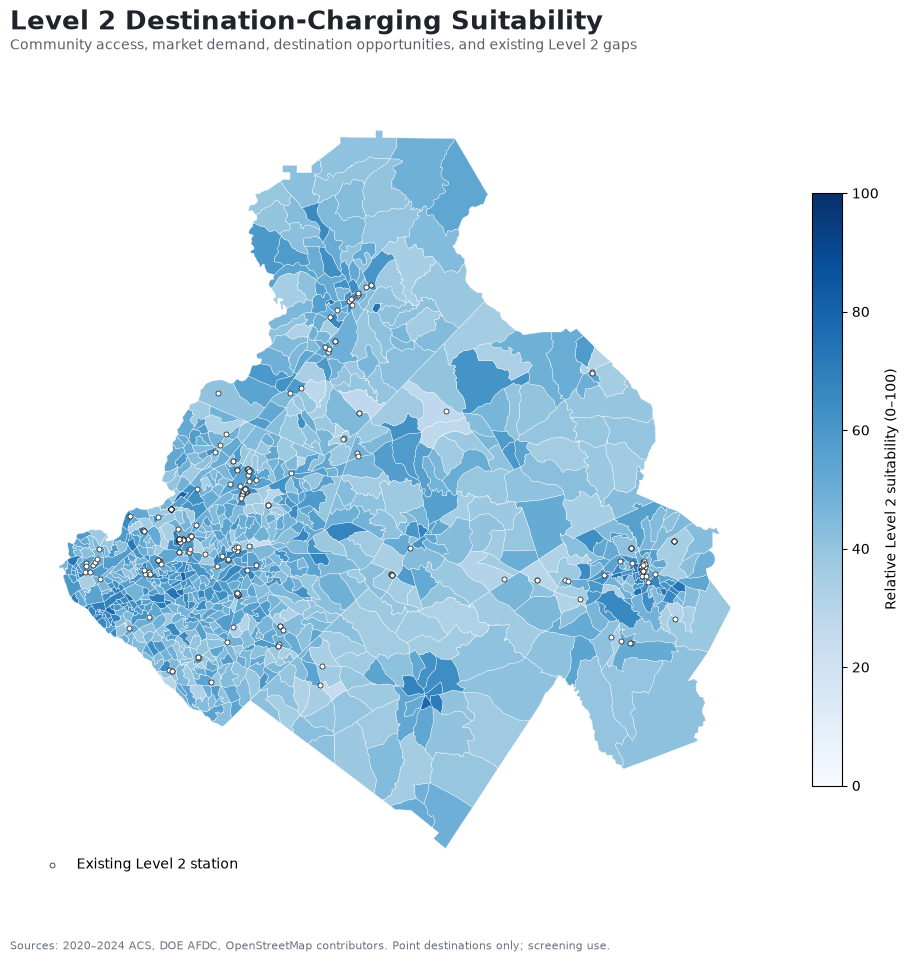

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\level2_destination_suitability.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 10), facecolor="white")
model.to_crs("EPSG:4326").plot(
    column="level2_suitability_score", ax=ax, cmap="Blues", vmin=0, vmax=100,
    edgecolor="white", linewidth=0.25, legend=True,
    legend_kwds={"label": "Relative Level 2 suitability (0–100)", "shrink": 0.75},
)
level2_stations.plot(ax=ax, facecolor="white", edgecolor="#20242A", marker="o", markersize=13, linewidth=0.55, label="Existing Level 2 station")
fig.suptitle("Level 2 Destination-Charging Suitability", x=0.04, y=0.965, ha="left", fontsize=19, weight="bold", color="#20242A")
fig.text(0.04, 0.925, "Community access, market demand, destination opportunities, and existing Level 2 gaps", ha="left", fontsize=10, color="#59616B")
ax.legend(frameon=False, loc="lower left")
ax.set_axis_off()
fig.text(0.04, 0.025, "Sources: 2020–2024 ACS, DOE AFDC, OpenStreetMap contributors. Point destinations only; screening use.", fontsize=8, color="#6B7280")
fig.subplots_adjust(left=0.03, right=0.90, top=0.88, bottom=0.09)

map_path = MAP_DIR / "level2_destination_suitability.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

## Validation

In [7]:
assert destinations[["osm_type", "osm_id"]].duplicated().sum() == 0
assert model["GEOID"].is_unique
assert len(model) == len(gap), "A join changed the block-group grain."
assert model["nearest_level2_miles"].notna().all()
assert model["level2_suitability_score"].between(0, 100).all()
assert model["destination_opportunity"].sum() == destinations["opportunity_weight"].sum(), "Destination weights did not reconcile after the spatial join."

expected_outputs = [
    SPATIAL_DIR / "level2_destination_opportunities.gpkg",
    SPATIAL_DIR / "level2_destination_suitability.gpkg",
    TABLE_DIR / "level2_destination_suitability_ranking.csv",
    MAP_DIR / "level2_destination_suitability.png",
]
assert all(path.exists() for path in expected_outputs)

print("All deduplication, join, reconciliation, score, and output checks passed.")
assert len(destinations) >= 300
print("Validation status: Share with caveats because OSM completeness, point-only feature scope, and site feasibility vary.")

All deduplication, join, reconciliation, score, and output checks passed.
Validation status: Share with caveats because OSM completeness, point-only feature scope, and site feasibility vary.


## Next Steps

Screen candidate land using developed land cover, flood and wetland exclusions, protected lands, parcel size, road access, and—where available—utility proximity.